## Extended Data Fig. 2a

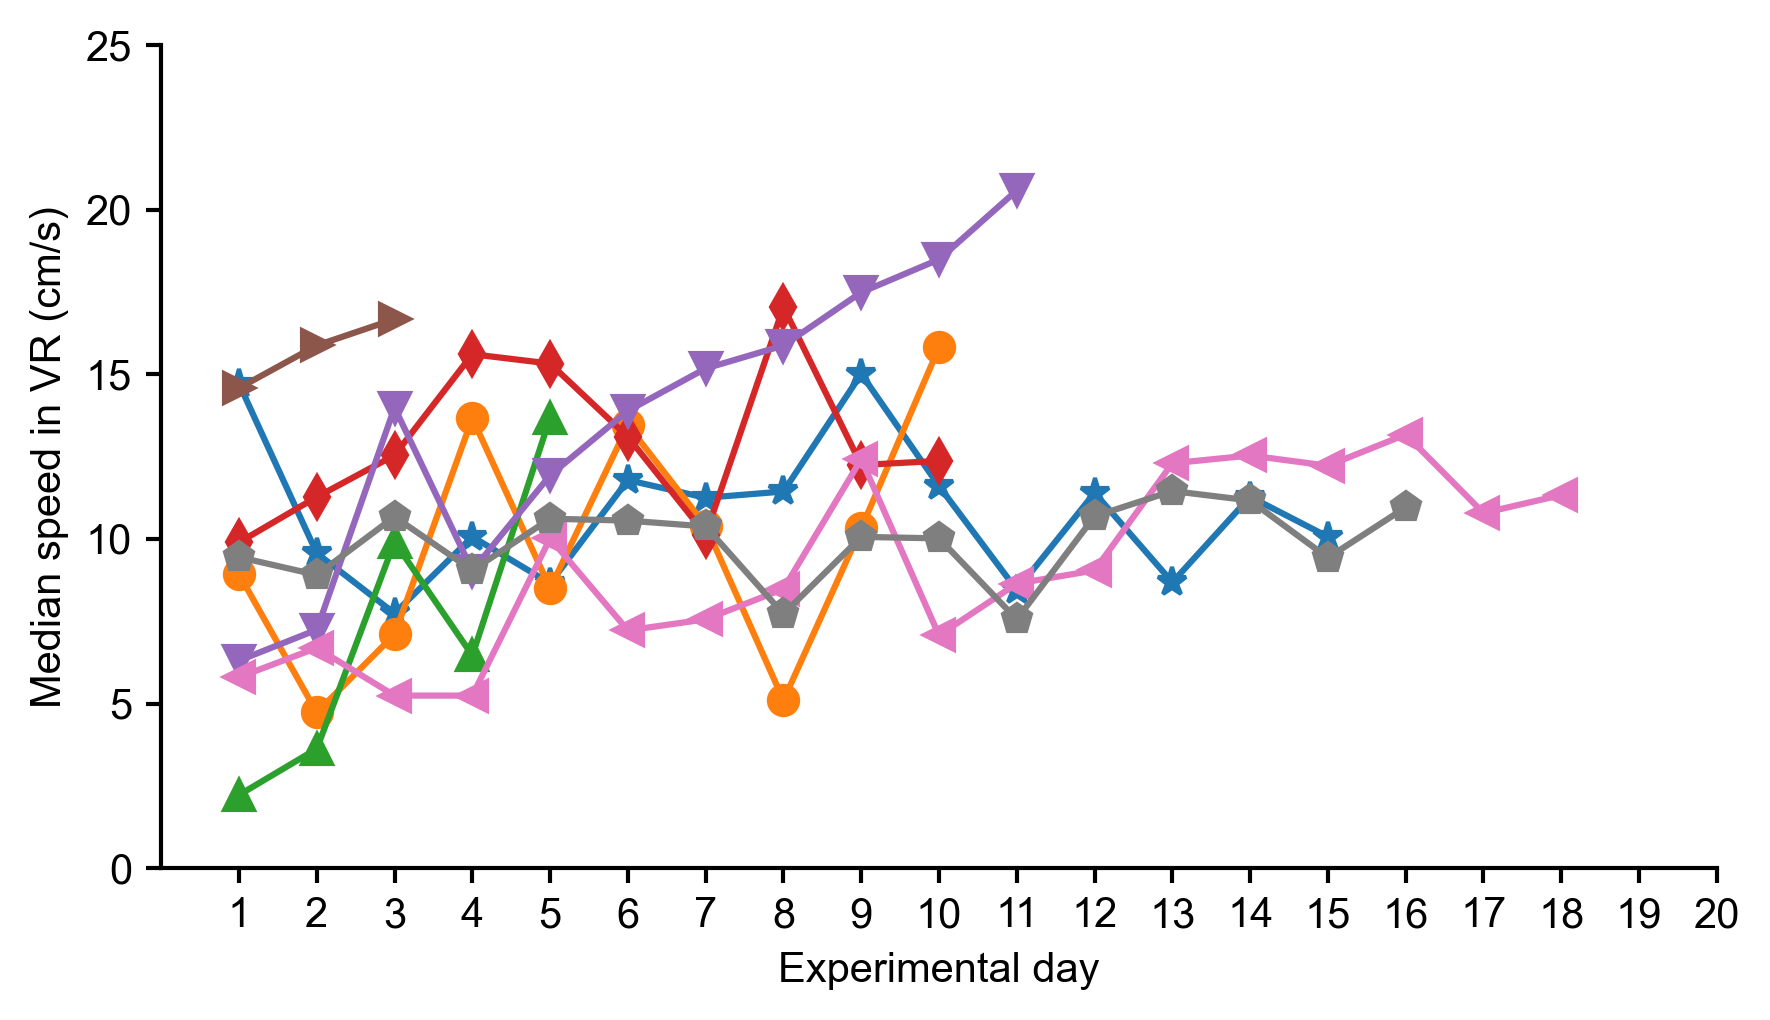

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat

mat = loadmat("../Results4Plots/medianspeedVR.mat", squeeze_me=True, struct_as_record=False)
ALLmedianspeedR1 = mat["ALLmedianspeedVR1"]
animalnos = ["m11", "m12", "m18", "m20", "m22", "m29", "m48", "m57"]
dashChangeDays = [15, 10, 5, 10, 11, 3, 18, 16]
marker_map = {
    "m11": "*",
    "m12": "o",
    "m18": "^",
    "m20": "d",
    "m22": "v",
    "m29": ">",
    "m48": "<",
    "m57": "p"
}
ALLmedianspeedR1 = [
    np.asarray(x, dtype=float).ravel()
    for x in np.atleast_1d(ALLmedianspeedR1)
]

color_order = plt.rcParams["axes.prop_cycle"].by_key()["color"]

fig, ax = plt.subplots(figsize=(6, 3.5), dpi=300)

for i, data in enumerate(ALLmedianspeedR1):
    animal = animalnos[i]
    end_day = min(dashChangeDays[i], len(data))
    days = np.arange(1, end_day + 1)

    ax.plot(
        days,
        data[:end_day],
        linewidth=1.5,
        color=color_order[i % len(color_order)],
        marker=marker_map.get(animal, "o"),
        markersize=7
    )

ax.set_xlabel("Experimental day", fontsize=10, fontname="Arial")
ax.set_ylabel("Median speed in VR (cm/s)", fontsize=10, fontname="Arial")
ax.set_xlim(0, 20)
ax.set_ylim(0, 25)
ax.set_xticks(np.arange(1, 21))
ax.set_yticks(np.arange(0, 26, 5))

ax.tick_params(axis="both", direction="out", length=3.5, width=1, labelsize=10)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1)
ax.spines["bottom"].set_linewidth(1)

for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontname("Arial")

plt.tight_layout()
plt.show()

## Extended Data Fig. 2b

Early R:
  n = 42
  mean = 9.435
  median = 9.244
  Q1 = 7.320
  Q3 = 11.267
  IQR = 3.947
  report style: 9.435, IQR [7.320, 11.267]

Late R:
  n = 46
  mean = 11.966
  median = 11.419
  Q1 = 10.062
  Q3 = 13.623
  IQR = 3.561
  report style: 11.966, IQR [10.062, 13.623]



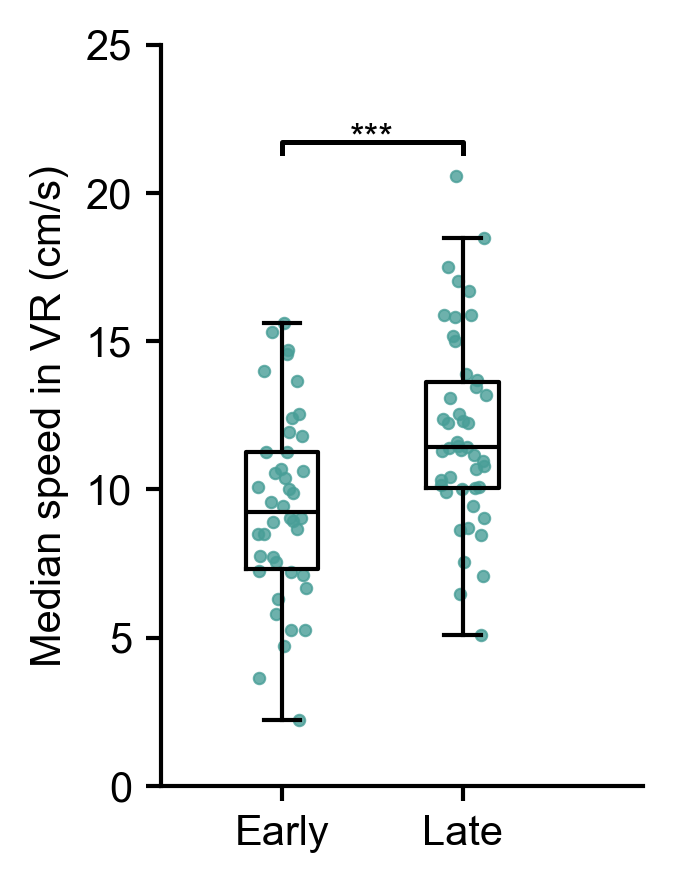

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat
ALLmedVR = [
    np.asarray(x, dtype=float).ravel()
    for x in np.atleast_1d(mat["ALLmedianspeedVR1"])
]

mergeDays = [
    [list(range(1, 8)), list(range(8, 16))],
    [list(range(1, 6)), list(range(6, 11))],
    [list(range(1, 3)), list(range(3, 6))],
    [list(range(1, 6)), list(range(6, 11))],
    [list(range(1, 6)), list(range(6, 12))],
    [[1], list(range(2, 4))],
    [list(range(1, 10)), list(range(10, 19))],
    [list(range(1, 9)), list(range(9, 17))]
]

early_R = []
late_R = []

for ia, values in enumerate(ALLmedVR):
    early_days, late_days = mergeDays[ia]

    for day, value in enumerate(values, start=1):
        if not np.isfinite(value):
            continue

        if day in early_days:
            early_R.append(value)
        elif day in late_days:
            late_R.append(value)

early_R = np.asarray(early_R, dtype=float)
late_R = np.asarray(late_R, dtype=float)

def print_summary(name, data):
    data = data[np.isfinite(data)]

    mean = np.mean(data)
    median = np.median(data)
    q1, q3 = np.percentile(data, [25, 75])

    print(f"{name}:")
    print(f"  n = {data.size}")
    print(f"  mean = {mean:.3f}")
    print(f"  median = {median:.3f}")
    print(f"  Q1 = {q1:.3f}")
    print(f"  Q3 = {q3:.3f}")
    print(f"  IQR = {q3 - q1:.3f}")
    print(f"  report style: {mean:.3f}, IQR [{q1:.3f}, {q3:.3f}]")
    print()

print_summary("Early R", early_R)
print_summary("Late R", late_R)

colorR = np.array([72, 158, 151]) / 255.0

rng = np.random.default_rng(0)
jitter_width = 0.4

def scatter_box(ax, x0, y):
    y = y[np.isfinite(y)]

    if y.size == 0:
        return

    jitter = (rng.random(y.size) - 0.5) * jitter_width

    ax.scatter(
        x0 + jitter,
        y,
        s=7.5,
        marker="o",
        facecolors=colorR,
        edgecolors=colorR,
        linewidths=0.5,
        alpha=0.8,
        zorder=3
    )

    bp = ax.boxplot(
        y,
        positions=[x0],
        widths=0.6,
        showfliers=False,
        patch_artist=False,
        boxprops=dict(color="k", linewidth=1),
        medianprops=dict(color="k", linewidth=1),
        whiskerprops=dict(color="k", linewidth=1),
        capprops=dict(color="k", linewidth=1)
    )

    for k in ["boxes", "medians", "whiskers", "caps"]:
        for artist in bp[k]:
            artist.set_zorder(10)

fig, ax = plt.subplots(figsize=(2.1, 2.8), dpi=300)

scatter_box(ax, 1, early_R)
scatter_box(ax, 2.5, late_R)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1)
ax.spines["bottom"].set_linewidth(1)

ax.tick_params(axis="both", direction="out", length=3.5, width=1.0, labelsize=10)

for label in ax.get_yticklabels():
    label.set_fontname("Arial")

ax.set_ylabel("Median speed in VR (cm/s)", fontsize=10, fontname="Arial")
ax.set_xticks([1, 2.5])
ax.set_xticklabels(["Early", "Late"], fontname="Arial", fontsize=10)
ax.set_xlim(0, 4)
ax.set_ylim(0, 25)

y_top = np.nanmax(np.concatenate([early_R, late_R]))
ymin, ymax = ax.get_ylim()
yr = ymax - ymin

h = 0.015 * yr
gap = 0.03 * yr
text_offset = 0.009 * yr-0.7
y = y_top + gap

ax.plot([1, 1, 2.5, 2.5], [y, y + h, y + h, y], lw=1.2, c="k")
ax.text(1.75, y + h + text_offset, "***", ha="center", va="bottom", fontname="Arial", fontsize=9)

ax.set_ylim(ymin, max(ymax, y + h + 3 * text_offset))

plt.tight_layout(pad=0.2)
plt.show()

## Extended Data Fig. 2c

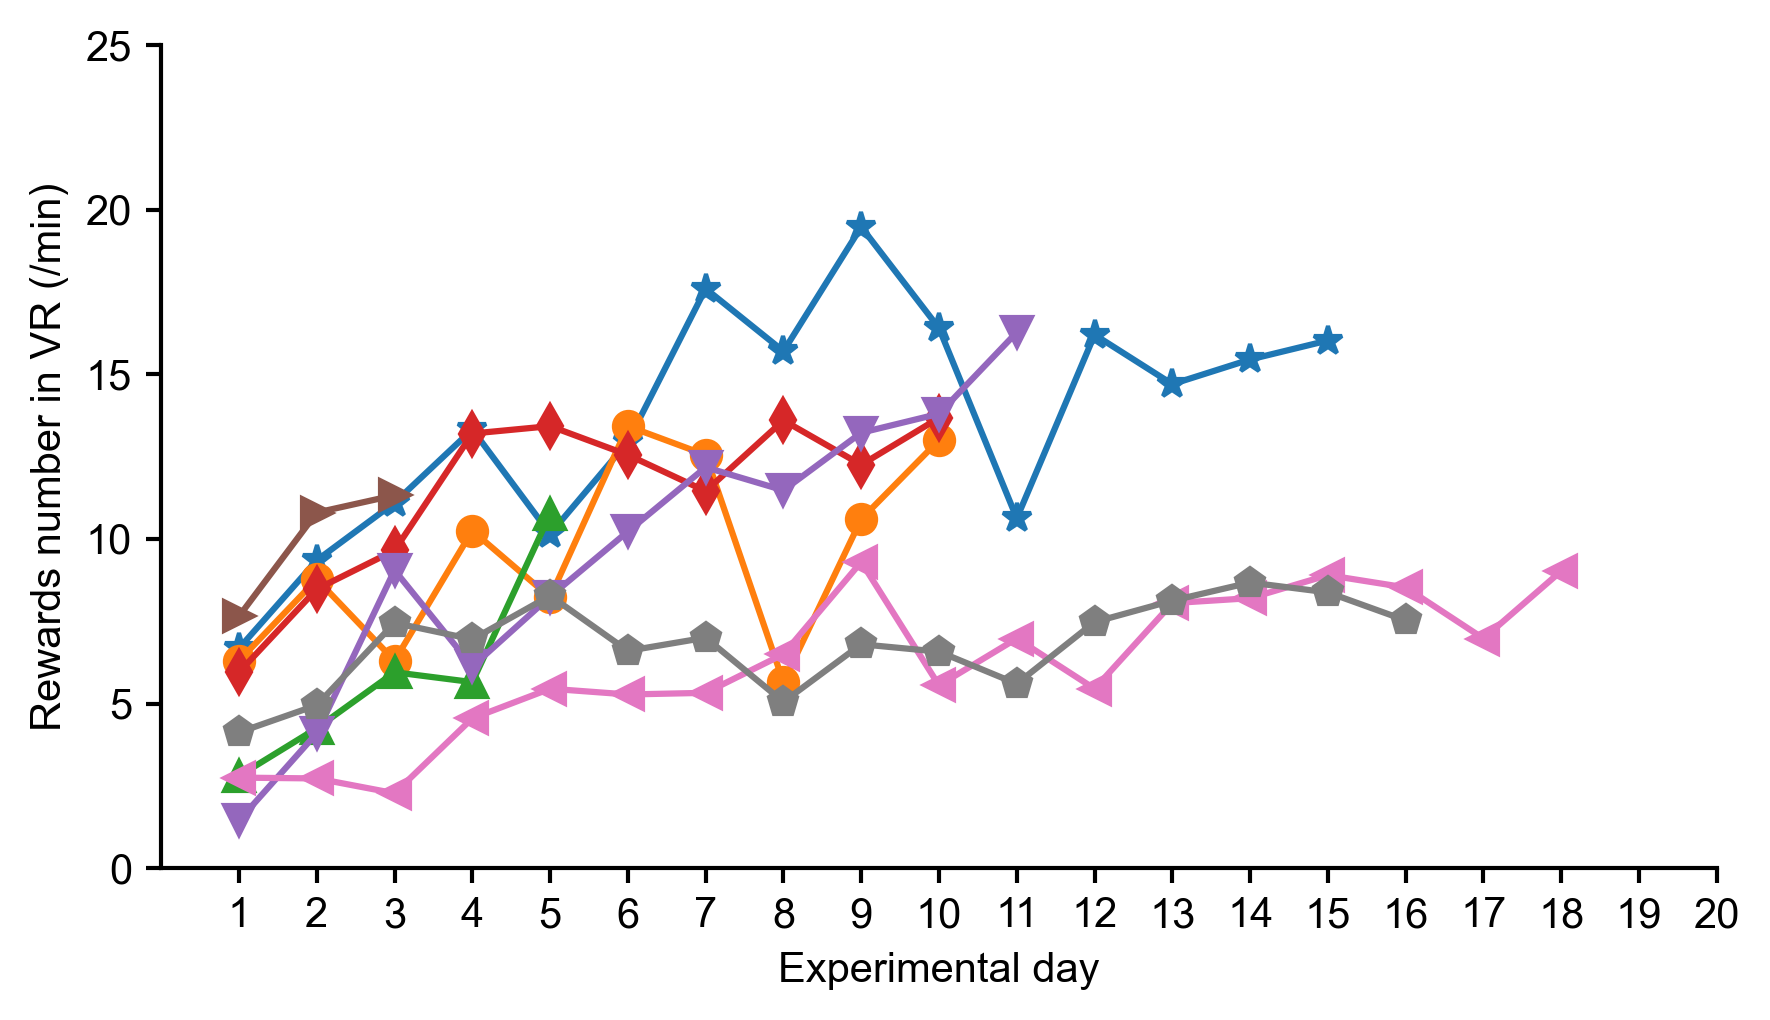

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat

mat = loadmat("../Results4Plots/rewardspermin.mat", squeeze_me=True, struct_as_record=False)
AllAnimalRewardsPerMins = mat["AllAnimalRewardsPerMins"]  # MATLAB cell
animalnos = ["m11", "m12", "m18", "m20", "m22", "m29", "m48", "m57"]
dashChangeDays = [15, 10, 5, 10, 11, 3, 18, 16]
marker_map = {
    "m11": "*",
    "m12": "o",
    "m18": "^",
    "m20": "d",
    "m22": "v",
    "m29": ">",
    "m48": "<",
    "m57": "p"
}
AllAnimalRewardsPerMins = [
    np.asarray(x, dtype=float).ravel()
    for x in np.atleast_1d(AllAnimalRewardsPerMins)
]

color_order = plt.rcParams["axes.prop_cycle"].by_key()["color"]

fig, ax = plt.subplots(figsize=(6, 3.5), dpi=300)

for i, data in enumerate(AllAnimalRewardsPerMins):
    animal = animalnos[i]
    end_day = min(dashChangeDays[i], len(data))
    days = np.arange(1, end_day + 1)

    ax.plot(
        days,
        data[:end_day],
        linewidth=1.5,
        color=color_order[i % len(color_order)],
        marker=marker_map.get(animal, "o"),
        markersize=7
    )

ax.set_xlabel("Experimental day", fontsize=10, fontname="Arial")
ax.set_ylabel("Rewards number in VR (/min)", fontsize=10, fontname="Arial")
ax.set_xlim(0, 20)
ax.set_ylim(0, 25)
ax.set_xticks(np.arange(1, 21))
ax.set_yticks(np.arange(0, 26, 5))

ax.tick_params(axis="both", direction="out", length=3.5, width=1, labelsize=10)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1)
ax.spines["bottom"].set_linewidth(1)

for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontname("Arial")

plt.tight_layout()
plt.show()

## Extended Data Fig. 2d

Early R:
  n = 42
  mean = 7.379
  median = 6.812
  Q1 = 5.106
  Q3 = 9.238
  IQR = 4.131
  report style: 7.379, IQR [5.106, 9.238]

Late R:
  n = 46
  mean = 10.691
  median = 10.688
  Q1 = 7.656
  Q3 = 13.375
  IQR = 5.719
  report style: 10.691, IQR [7.656, 13.375]



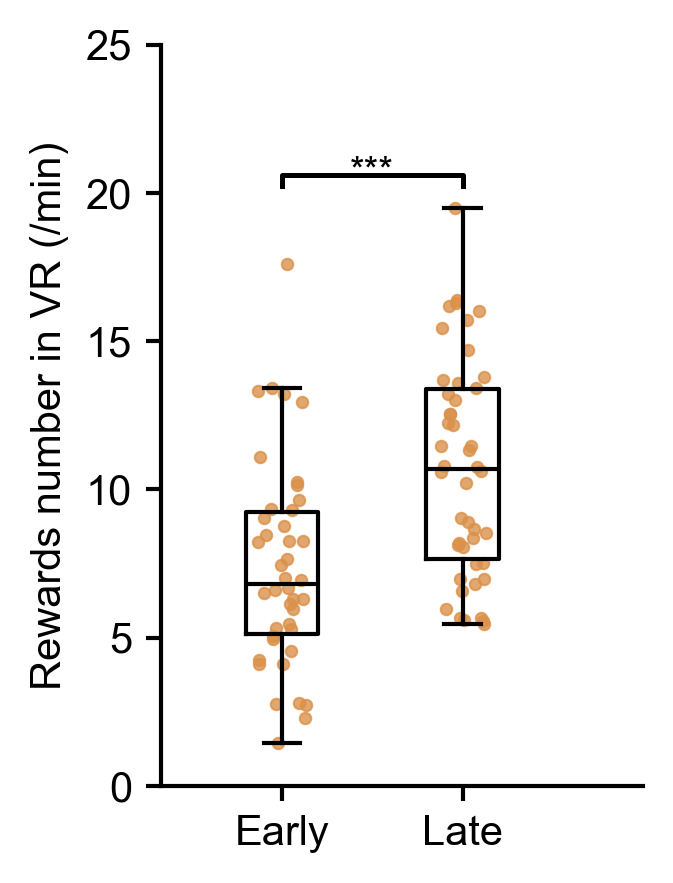

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat

mat = loadmat("../Results4Plots/rewardspermin.mat", squeeze_me=True, struct_as_record=False)

ALLmedR = [
    np.asarray(x, dtype=float).ravel()
    for x in np.atleast_1d(mat["AllAnimalRewardsPerMins"])
]

mergeDays = [
    [list(range(1, 8)), list(range(8, 16))],
    [list(range(1, 6)), list(range(6, 11))],
    [list(range(1, 3)), list(range(3, 6))],
    [list(range(1, 6)), list(range(6, 11))],
    [list(range(1, 6)), list(range(6, 12))],
    [[1], list(range(2, 4))],
    [list(range(1, 10)), list(range(10, 19))],
    [list(range(1, 9)), list(range(9, 17))]
]

early_R = []
late_R = []

for ia, values in enumerate(ALLmedR):
    early_days, late_days = mergeDays[ia]

    for day, value in enumerate(values, start=1):
        if not np.isfinite(value):
            continue

        if day in early_days:
            early_R.append(value)
        elif day in late_days:
            late_R.append(value)

early_R = np.asarray(early_R, dtype=float)
late_R = np.asarray(late_R, dtype=float)

def print_summary(name, data):
    data = data[np.isfinite(data)]

    mean = np.mean(data)
    median = np.median(data)
    q1, q3 = np.percentile(data, [25, 75])

    print(f"{name}:")
    print(f"  n = {data.size}")
    print(f"  mean = {mean:.3f}")
    print(f"  median = {median:.3f}")
    print(f"  Q1 = {q1:.3f}")
    print(f"  Q3 = {q3:.3f}")
    print(f"  IQR = {q3 - q1:.3f}")
    print(f"  report style: {mean:.3f}, IQR [{q1:.3f}, {q3:.3f}]")
    print()

print_summary("Early R", early_R)
print_summary("Late R", late_R)

colorR = np.array([218, 145, 74]) / 255.0

rng = np.random.default_rng(0)
jitter_width = 0.4

def scatter_box(ax, x0, y):
    y = y[np.isfinite(y)]

    if y.size == 0:
        return

    jitter = (rng.random(y.size) - 0.5) * jitter_width

    ax.scatter(
        x0 + jitter,
        y,
        s=7.5,
        marker="o",
        facecolors=colorR,
        edgecolors=colorR,
        linewidths=0.5,
        alpha=0.8,
        zorder=3
    )

    bp = ax.boxplot(
        y,
        positions=[x0],
        widths=0.6,
        showfliers=False,
        patch_artist=False,
        boxprops=dict(color="k", linewidth=1),
        medianprops=dict(color="k", linewidth=1),
        whiskerprops=dict(color="k", linewidth=1),
        capprops=dict(color="k", linewidth=1)
    )

    for k in ["boxes", "medians", "whiskers", "caps"]:
        for artist in bp[k]:
            artist.set_zorder(10)

fig, ax = plt.subplots(figsize=(2.1, 2.8), dpi=300)

scatter_box(ax, 1, early_R)
scatter_box(ax, 2.5, late_R)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1)
ax.spines["bottom"].set_linewidth(1)

ax.tick_params(axis="both", direction="out", length=3.5, width=1.0, labelsize=10)

for label in ax.get_yticklabels():
    label.set_fontname("Arial")

ax.set_ylabel("Rewards number in VR (/min)", fontsize=10, fontname="Arial")
ax.set_xticks([1, 2.5])
ax.set_xticklabels(["Early", "Late"], fontname="Arial", fontsize=10)
ax.set_xlim(0, 4)
ax.set_ylim(0, 25)

y_top = np.nanmax(np.concatenate([early_R, late_R]))
ymin, ymax = ax.get_ylim()
yr = ymax - ymin

h = 0.015 * yr
gap = 0.03 * yr
text_offset = 0.009 * yr-0.7
y = y_top + gap

ax.plot([1, 1, 2.5, 2.5], [y, y + h, y + h, y], lw=1.2, c="k")
ax.text(1.75, y + h + text_offset, "***", ha="center", va="bottom", fontname="Arial", fontsize=9)

ax.set_ylim(ymin, max(ymax, y + h + 3 * text_offset))

plt.tight_layout(pad=0.2)
plt.show()

## Extended Data Fig. 2e

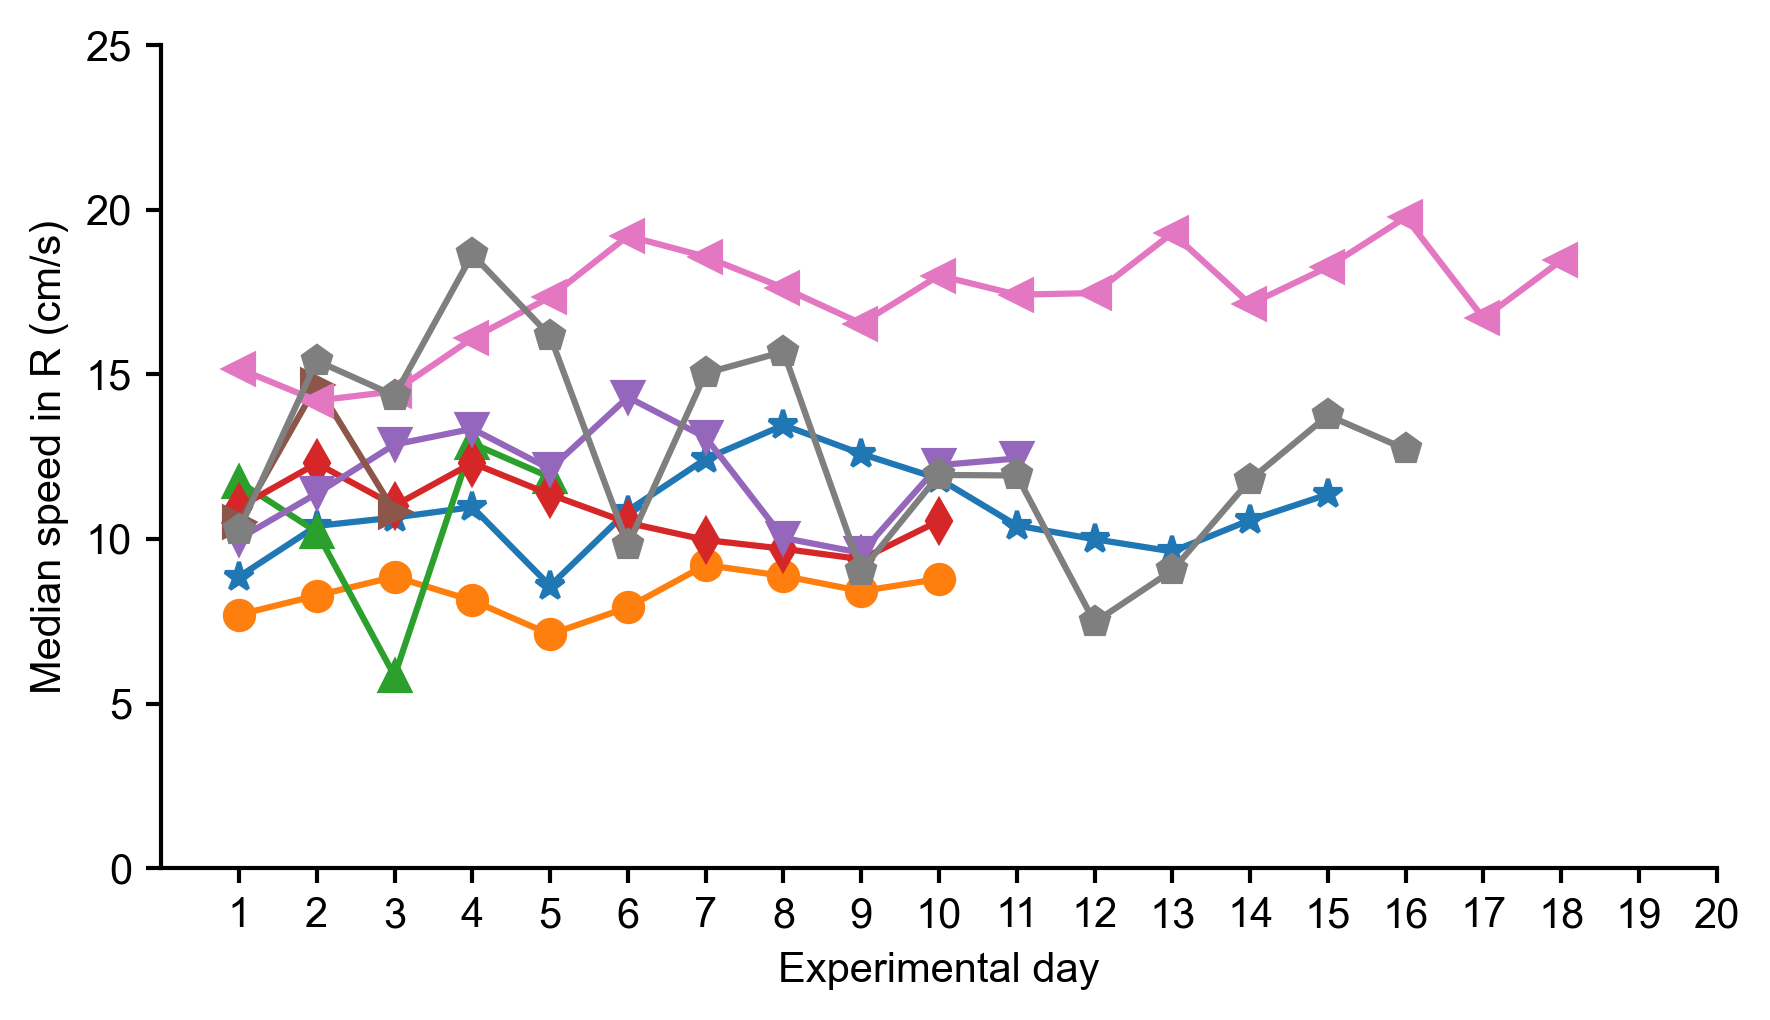

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat

mat = loadmat("../Results4Plots/medianspeedR.mat", squeeze_me=True, struct_as_record=False)
ALLmedianspeedR1 = mat["ALLmedianspeedR1"]
animalnos = ["m11", "m12", "m18", "m20", "m22", "m29", "m48", "m57"]
dashChangeDays = [15, 10, 5, 10, 11, 3, 18, 16]
marker_map = {
    "m11": "*",
    "m12": "o",
    "m18": "^",
    "m20": "d",
    "m22": "v",
    "m29": ">",
    "m48": "<",
    "m57": "p"
}
ALLmedianspeedR1 = [
    np.asarray(x, dtype=float).ravel()
    for x in np.atleast_1d(ALLmedianspeedR1)
]

color_order = plt.rcParams["axes.prop_cycle"].by_key()["color"]

fig, ax = plt.subplots(figsize=(6, 3.5), dpi=300)

for i, data in enumerate(ALLmedianspeedR1):
    animal = animalnos[i]
    end_day = min(dashChangeDays[i], len(data))
    days = np.arange(1, end_day + 1)

    ax.plot(
        days,
        data[:end_day],
        linewidth=1.5,
        color=color_order[i % len(color_order)],
        marker=marker_map.get(animal, "o"),
        markersize=7
    )

ax.set_xlabel("Experimental day", fontsize=10, fontname="Arial")
ax.set_ylabel("Median speed in R (cm/s)", fontsize=10, fontname="Arial")
ax.set_xlim(0, 20)
ax.set_ylim(0, 25)
ax.set_xticks(np.arange(1, 21))
ax.set_yticks(np.arange(0, 26, 5))

ax.tick_params(axis="both", direction="out", length=3.5, width=1, labelsize=10)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1)
ax.spines["bottom"].set_linewidth(1)

for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontname("Arial")

plt.tight_layout()
plt.show()

## Extended Data Fig. 2f

Early R:
  n = 42
  mean = 12.559
  median = 11.931
  Q1 = 10.300
  Q3 = 15.133
  IQR = 4.833
  report style: 12.559, IQR [10.300, 15.133]

Late R:
  n = 46
  mean = 12.196
  median = 11.811
  Q1 = 9.640
  Q3 = 13.676
  IQR = 4.036
  report style: 12.196, IQR [9.640, 13.676]



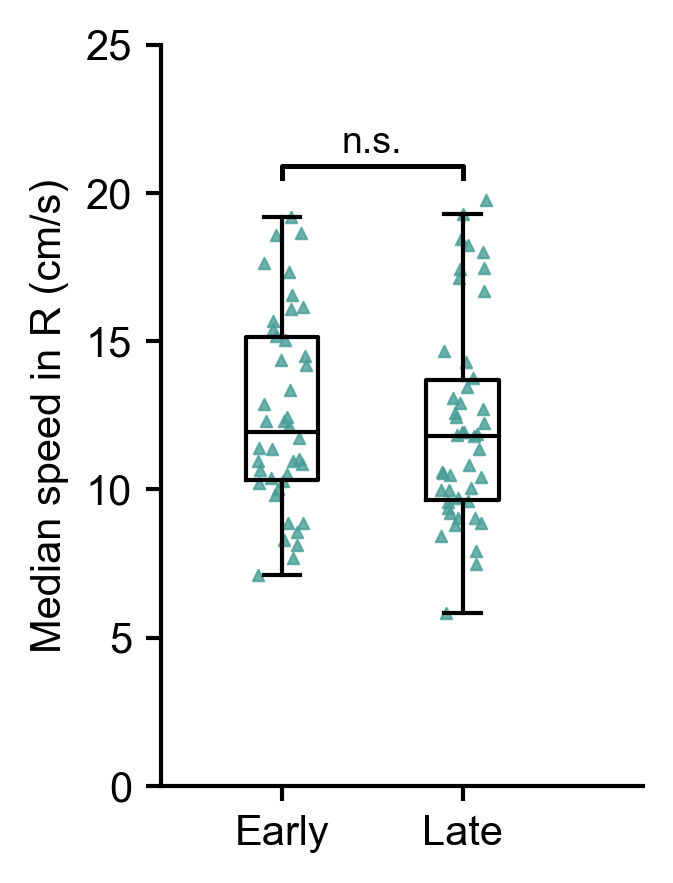

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat

mat = loadmat("../Results4Plots/medianspeedR.mat", squeeze_me=True, struct_as_record=False)

ALLmedR = [
    np.asarray(x, dtype=float).ravel()
    for x in np.atleast_1d(mat["ALLmedianspeedR1"])
]

mergeDays = [
    [list(range(1, 8)), list(range(8, 16))],
    [list(range(1, 6)), list(range(6, 11))],
    [list(range(1, 3)), list(range(3, 6))],
    [list(range(1, 6)), list(range(6, 11))],
    [list(range(1, 6)), list(range(6, 12))],
    [[1], list(range(2, 4))],
    [list(range(1, 10)), list(range(10, 19))],
    [list(range(1, 9)), list(range(9, 17))]
]

early_R = []
late_R = []

for ia, values in enumerate(ALLmedR):
    early_days, late_days = mergeDays[ia]

    for day, value in enumerate(values, start=1):
        if not np.isfinite(value):
            continue

        if day in early_days:
            early_R.append(value)
        elif day in late_days:
            late_R.append(value)

early_R = np.asarray(early_R, dtype=float)
late_R = np.asarray(late_R, dtype=float)

def print_summary(name, data):
    data = data[np.isfinite(data)]

    mean = np.mean(data)
    median = np.median(data)
    q1, q3 = np.percentile(data, [25, 75])

    print(f"{name}:")
    print(f"  n = {data.size}")
    print(f"  mean = {mean:.3f}")
    print(f"  median = {median:.3f}")
    print(f"  Q1 = {q1:.3f}")
    print(f"  Q3 = {q3:.3f}")
    print(f"  IQR = {q3 - q1:.3f}")
    print(f"  report style: {mean:.3f}, IQR [{q1:.3f}, {q3:.3f}]")
    print()

print_summary("Early R", early_R)
print_summary("Late R", late_R)

colorR = np.array([72, 158, 151]) / 255.0

rng = np.random.default_rng(0)
jitter_width = 0.4

def scatter_box(ax, x0, y):
    y = y[np.isfinite(y)]

    if y.size == 0:
        return

    jitter = (rng.random(y.size) - 0.5) * jitter_width

    ax.scatter(
        x0 + jitter,
        y,
        s=7.5,
        marker="^",
        facecolors=colorR,
        edgecolors=colorR,
        linewidths=0.5,
        alpha=0.8,
        zorder=3
    )

    bp = ax.boxplot(
        y,
        positions=[x0],
        widths=0.6,
        showfliers=False,
        patch_artist=False,
        boxprops=dict(color="k", linewidth=1),
        medianprops=dict(color="k", linewidth=1),
        whiskerprops=dict(color="k", linewidth=1),
        capprops=dict(color="k", linewidth=1)
    )

    for k in ["boxes", "medians", "whiskers", "caps"]:
        for artist in bp[k]:
            artist.set_zorder(10)

fig, ax = plt.subplots(figsize=(2.1, 2.8), dpi=300)

scatter_box(ax, 1, early_R)
scatter_box(ax, 2.5, late_R)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1)
ax.spines["bottom"].set_linewidth(1)

ax.tick_params(axis="both", direction="out", length=3.5, width=1.0, labelsize=10)

for label in ax.get_yticklabels():
    label.set_fontname("Arial")

ax.set_ylabel("Median speed in R (cm/s)", fontsize=10, fontname="Arial")
ax.set_xticks([1, 2.5])
ax.set_xticklabels(["Early", "Late"], fontname="Arial", fontsize=10)
ax.set_xlim(0, 4)
ax.set_ylim(0, 25)

y_top = np.nanmax(np.concatenate([early_R, late_R]))
ymin, ymax = ax.get_ylim()
yr = ymax - ymin

h = 0.015 * yr
gap = 0.03 * yr
text_offset = 0.009 * yr
y = y_top + gap

ax.plot([1, 1, 2.5, 2.5], [y, y + h, y + h, y], lw=1.2, c="k")
ax.text(1.75, y + h + text_offset, "n.s.", ha="center", va="bottom", fontname="Arial", fontsize=9)

ax.set_ylim(ymin, max(ymax, y + h + 3 * text_offset))

plt.tight_layout(pad=0.2)
plt.show()